# Deep Operator Network (DeepONets) in Neuromancer: Learning nonlinear operators

This tutorial demonstrates the use of Deep Operator Network (DeepONets) for solving partial differential equations (PDEs) in the Neuromancer library.

<img src="https://media.springernature.com/lw685/springer-static/image/art%3A10.1038%2Fs42256-021-00302-5/MediaObjects/42256_2021_302_Fig1_HTML.png" width="700">  

## Deep Operator Networks (DeepONets)

DeepONets are neural networks designed to learn **operators**, i.e. mappings between functions,
$$
\mathcal{G} : v(\cdot) \;\mapsto\; u(\cdot),
$$
where $ v $ is an input function (e.g. a source term or coefficient field) and $ u $ is the corresponding output function (e.g. the PDE solution).

A DeepONet represents the operator evaluation at a point $ x $ as
$$
u(x) \approx \sum_{k=1}^{p} b_k(v)\, t_k(x),
$$
where:
- $ b_k(v) $ are outputs of the **branch network**, which encodes the input function $ v $ sampled at fixed sensor locations,
- $ t_k(x) $ are outputs of the **trunk network**, which encodes the spatial coordinate $ x $,
- $ p $ is the latent dimension.

Equivalently, this can be written as an inner product:
$$
u(x) \approx \mathbf{b}(v)^\top \mathbf{t}(x).
$$

In the **Cartesian-product formulation**, the same branch encoding $ \mathbf{b}(v) $ is paired with many spatial locations $ x $, allowing efficient evaluation of the output function on structured grids.

DeepONets provide a principled framework for learning solution operators of partial differential equations and have universal approximation properties for nonlinear operators.

### References

[1] [Lu, L., Jin, P., Pang, G. et al. Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators. Nat Mach Intell 3, 218–229 (2021).](https://www.nature.com/articles/s42256-021-00302-5)

[2] https://github.com/jdtoscano94/Learning-Python-Physics-Informed-Machine-Learning-PINNs-DeepONets/tree/main

[3] [Lu, L., Meng, X., Cai, S., Mao, Z., Goswami, S., Zhang, Z., & Karniadakis, G. E. (2022). A comprehensive and fair comparison of two neural operators (with practical extensions) based on fair data. Computer Methods in Applied Mechanics and Engineering, 393, 114778.](https://www.sciencedirect.com/science/article/pii/S0045782522001207?via%3Dihub)

# Antiderivative Operator - Aligned Dataset

This tutorial demonstrates the use of learning DeepONets for a data driven use case (non-physics informed). This tutorial demonstrates usage of a Cartesian-product DeepONet implemented in Neuromancer, which is compatible with `neuromancer.modules.blocks` (or any `nn.Module`). The capability to use DeepONets from DeepXDE library within Neuromancer is also demonstrated. Here, we use `dde.nn.DeepONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`


### References
[1] [Antiderivative operator from an aligned dataset - DeepXDE](https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_aligned.html)

[2] [DeepONet Tutorial in JAX](https://github.com/Ceyron/machine-learning-and-simulation/blob/main/english/neural_operators/simple_deepOnet_in_JAX.ipynb)

[3] [DeepXDE DeepONet PyTorch backend](https://deepxde.readthedocs.io/en/stable/_modules/deepxde/nn/pytorch/deeponet.html#)

[4] https://docs.nvidia.com/physicsnemo/25.08/physicsnemo-sym/user_guide/neural_operators/deeponet.html

### Install (Colab only)

In [1]:
# %pip install "neuromancer[examples] @ git+https://github.com/pnnl/neuromancer.git@master"
# %pip install watermark

### Imports

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [3]:
# PyTorch random seed
torch.manual_seed(1234)

# NumPy random seed
np.random.seed(1234)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Problem Setup

original source: [https://github.com/lululxvi/deepxde/blob/master/examples/operator/poisson_1d_pideeponet.py](https://github.com/lululxvi/deepxde/blob/master/examples/operator/poisson_1d_pideeponet.py)  

We will learn the 1D Poisson operator:

$$G : v \mapsto u$$

Find u on [0,1] such that -u_xx(x) = f(x) with Dirichlet u(0)=u(1)=0. Here f is not fixed; we learn the solution operator that maps any admissible f (from a small function space) to its corresponding u.

## Problem definition

PDE Definition:

The PDE is the 1D advection equation: 
$$(\frac{\partial y}{\partial t} + \frac{\partial y}{\partial x} = 0)$$

where $y(x, t)$ is the solution, $x$ is spatial coordinate, and $t$ is time.
This represents wave propagation without diffusion, with the solution advecting in the positive x-direction.

In [4]:
# Poisson equation: -u_xx = f
def pde(x, y, v):
    dy_x = dde.grad.jacobian(y, x, j=0)
    dy_t = dde.grad.jacobian(y, x, j=1)
    return dy_t + dy_x

Geometry and Boundary Conditions:

- Spatial domain: Interval ([0, 1]) for (x).
- Time domain: TimeDomain ([0, 1]) for (t).
- Combined geometry: geomtime = `dde.geometry.GeometryXTime(geom, timedomain)`, a spatiotemporal domain.

In [5]:
# Domain is interval [0, 1] in both space and time
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

Initial condition (IC): 
At $t=0$, 
$y(x, 0) = v(x)$, where $v(x)$ is a function from a function space

In [6]:
def func_ic(x, v):
    return v


ic = dde.icbc.IC(geomtime, func_ic, lambda _, on_initial: on_initial)

## Dataset Prep

Create a `dde.data.TimePDE` object for time-dependent PDEs. It samples 250 points in the domain, 50 on the initial boundary at $t=0$, and 500 test points for evaluation.


In [7]:
# Define PDE
pde = dde.data.TimePDE(geomtime, pde, ic, num_domain=250, num_initial=50, num_test=400)

Training points:
- `train_x_all`: ~250 interior spatio‑temporal points + 50 initial points ($t=0$).
- `train_x_bc`: the IC points (≈50) filtered from `train_x_all`.
- `train_x`: `train_x_bc` stacked with `train_x_all` (IC points appear twice because BC and PDE losses use separate slices).


Test points:
- `test_x`: `train_x_bc` + 400 uniformly sampled interior points

In [8]:
n_bc = sum(pde.num_bcs)
print(n_bc)
print("train_x", pde.train_x.shape)
print("train_x_all", pde.train_x_all.shape)
print("train_x_bc", pde.train_x_bc.shape)  # (350, 2)
print("test_x ", pde.test_x.shape)
print("BC x identical on test/train? ", np.allclose(pde.test_x[:n_bc], pde.train_x_bc))

50
train_x (350, 2)
train_x_all (300, 2)
train_x_bc (50, 2)
test_x  (450, 2)
BC x identical on test/train?  True


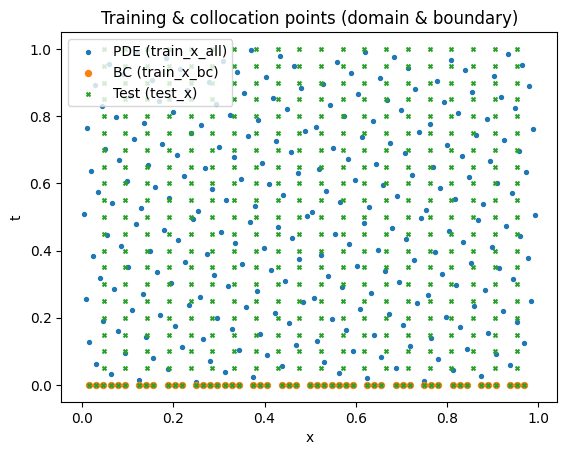

In [9]:
# grab points, display x-cordinates

plt.figure()
plt.scatter(
    pde.train_x_all[:, 0], pde.train_x_all[:, 1], s=8, label="PDE (train_x_all)"
)
plt.scatter(pde.train_x_bc[:, 0], pde.train_x_bc[:, 1], s=18, label="BC (train_x_bc)")
plt.scatter(pde.test_x[:, 0], pde.test_x[:, 1], s=8, marker="x", label="Test (test_x)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Training & collocation points (domain & boundary)")
plt.legend()
plt.show()

Sample $v$ from a Gaussian random field (GRF)

Use the [GRF data generator from dde](https://deepxde.readthedocs.io/en/latest/_modules/deepxde/data/function_spaces.html#GRF) to sample a chosen dataset size.

In [10]:
# Function space with N=1000 (default)
func_space = dde.data.GRF(kernel="ExpSineSquared", length_scale=1)

Text(0, 0.5, 'v(x)')

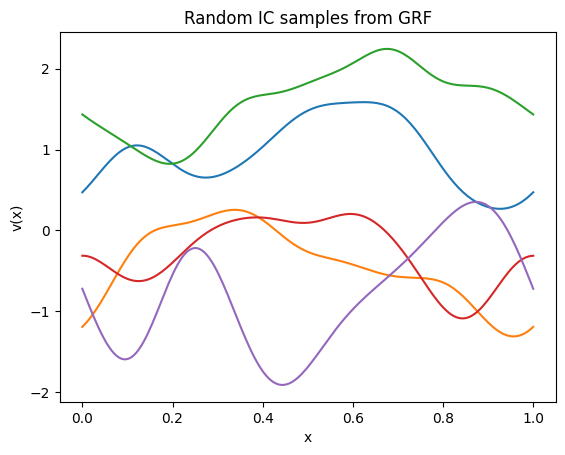

In [11]:
# 2) Sample a few GRF functions (input ICs)
xs = np.linspace(0, 1, 200)[:, None]
feats = func_space.random(5)
vals = func_space.eval_batch(feats, xs)
plt.figure()
for i in range(vals.shape[0]):
    plt.plot(xs.ravel(), vals[i])
plt.title("Random IC samples from GRF")
plt.xlabel("x")
plt.ylabel("v(x)")

50 evenly spaced evaluation points in $[0, 1]$ for $x$

In [12]:
# Data
eval_pts = np.linspace(0, 1, num=50)[:, None]

`PDEOperatorCartesianProd` builds the operator-learning dataset

It samples `num_function` random f from `function_space`, evaluates them at `evaluation_points` for branch inputs, evaluates them at all PDE collocation points for auxiliary vars, and pairs each branch sample with the fixed trunk grid.

After construction, `data` contains the following fields:

- **`data.eval_pts`**  
  The evaluation points used to sample each function $f$ for the branch network.  
  Shape: `(num_eval_points,) = (50,)`

- **`data.train_x`**  
  Tuple `(func_vals, pde.train_x)` containing branch and trunk inputs.

  - **`func_vals`**  
    Branch inputs: values of each sampled function evaluated at `eval_pts`.  
    Shape: `(num_function, num_eval_points) = (1000, 50)`

  - **`pde.train_x`**  
    Trunk inputs: PDE collocation points in $(x,t)$ (interior + boundary).  
    Shape: `(num_domain + num_boundary, dim) = (350, 2)`

In [13]:
# Define PDE operator
data = dde.data.PDEOperatorCartesianProd(
    pde,
    function_space=func_space,
    evaluation_points=eval_pts,
    num_function=1000,
    function_variables=[0],
    num_test=100,
    batch_size=32,
)

In [14]:
# Branch inputs: f values at the 10 evaluation points
f_vals, x_trunk = data.train_x  # f_vals shape: (1000, 350); x_trunk shape: (350, 2)
eval_pts = data.eval_pts  # same 10-point grid used for branch inputs
f_trunk = data.train_aux_vars  # (Nf, m_trunk) = f(x) on trunk grid
print("eval_pts.shape ", eval_pts.shape)
print("x_trunk.shape ", x_trunk.shape)
print("f_vals.shape    ", f_vals.shape)
print("f_trunk.shape ", f_trunk.shape)

eval_pts.shape  (50, 1)
x_trunk.shape  (350, 2)
f_vals.shape     (1000, 50)
f_trunk.shape  (1000, 350)


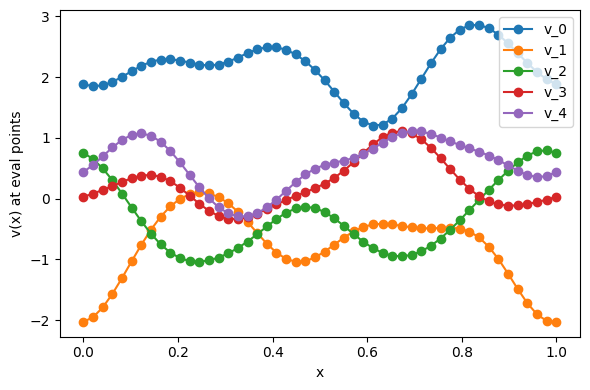

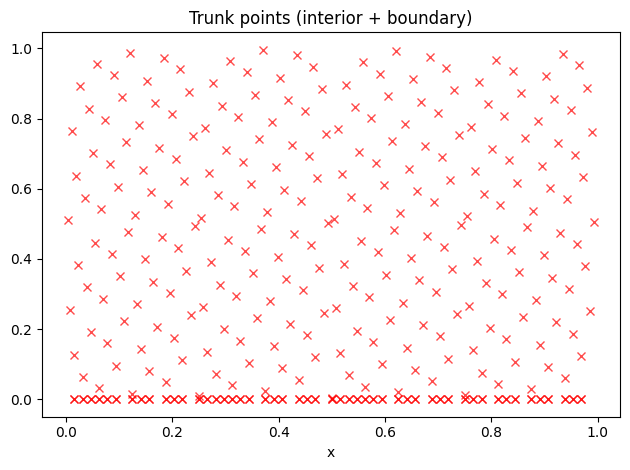

In [15]:
# Plot a few sampled source terms on the eval grid
plt.figure(figsize=(6, 4))
for i in range(5):
    plt.plot(eval_pts[:, 0], f_vals[i], marker="o", label=f"v_{i}")
plt.xlabel("x")
plt.ylabel("v(x) at eval points")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize trunk (PDE collocation + boundary) points
# plt.figure(figsize=(6, 2))
plt.plot(x_trunk[:, 0], x_trunk[:, 1], "rx", alpha=0.7)
plt.xlabel("x")
# plt.yticks([])
plt.title("Trunk points (interior + boundary)")
plt.tight_layout()
plt.show()

In [16]:
## Create data for testing
(f_vals_test, x_trunk_test) = data.test_x
f_trunk_test = data.test_aux_vars  # (Nf, m_trunk) = f(x) on trunk grid

In [17]:
print("x_trunk_test.shape ", x_trunk_test.shape)
print("f_vals_test.shape    ", f_vals_test.shape)
print("f_trunk_test.shape ", f_trunk_test.shape)

x_trunk_test.shape  (450, 2)
f_vals_test.shape     (100, 50)
f_trunk_test.shape  (100, 450)


## Creating datasets for Neuromancer

- Branch input shape (`num_function, num_eval_points`) = (100,10): values of each sampled $f$ at the 10 evaluation points.
- Trunk input shape (`num_pde_pts`, `dim_x`) = (`pde.train_x.shape[0]`, `1`): spatial coordinates used for PDE residual + BC enforcement.


`requires_grad_()` here ensures the trunk coords participate in autograd when we differentiate `u(x)`. This will be needed for physics losses


In [18]:
from neuromancer.dataset import DictDataset

branch_inputs = torch.as_tensor(f_vals, dtype=torch.float32)  # (Nf, m_eval)
trunk_grid = torch.as_tensor(x_trunk, dtype=torch.float32)  # (m_trunk, dim_x)
trunk_inputs = trunk_grid.expand(
    branch_inputs.shape[0], -1, -1
).requires_grad_()  # (Nf, m_trunk, dim_x) shared grid, grad on for physics loss
f_out_trunk = torch.as_tensor(f_trunk, dtype=torch.float32)  # (Nf, m_trunk)

train_datadict = DictDataset(
    {
        "branch_inputs": branch_inputs,
        "trunk_inputs": trunk_inputs,
        "outputs": f_out_trunk,
    },
    name="train",
)

In [19]:
branch_inputs_test = torch.as_tensor(f_vals_test, dtype=torch.float32)  # (Nf, m_eval)
trunk_grid_test = torch.as_tensor(x_trunk_test, dtype=torch.float32)  # (m_trunk, dim_x)
trunk_inputs_test = trunk_grid_test.expand(
    branch_inputs_test.shape[0], -1, -1
).requires_grad_()  # (Nf, m_trunk, dim_x) shared grid, grad on for physics loss
f_out_trunk_test = torch.as_tensor(f_trunk_test, dtype=torch.float32)  # (Nf, m_trunk)

test_datadict = DictDataset(
    {
        "branch_inputs": branch_inputs_test,
        "trunk_inputs": trunk_inputs_test,
        "outputs": f_out_trunk_test,
    },
    name="test",
)

### Create named dictionary datasets

In [20]:
# check dimensions
print("Dimensions check:")
print("Train branch:", train_datadict.datadict["branch_inputs"].shape)  # (Nf, m_eval)
print("Train output:", train_datadict.datadict["outputs"].shape)  # (Nf, m_trunk)
print(
    "Train trunk:", train_datadict.datadict["trunk_inputs"].shape
)  # (Nf, m_trunk, dim_x)

print("Test branch:", test_datadict.datadict["branch_inputs"].shape)  # (Nf, m_eval)
print("Test output:", test_datadict.datadict["outputs"].shape)  # (Nf, m_trunk)
print(
    "Test trunk:", test_datadict.datadict["trunk_inputs"].shape
)  # (Nf, m_trunk, dim_x)

Dimensions check:
Train branch: torch.Size([1000, 50])
Train output: torch.Size([1000, 350])
Train trunk: torch.Size([1000, 350, 2])
Test branch: torch.Size([100, 50])
Test output: torch.Size([100, 450])
Test trunk: torch.Size([100, 450, 2])


### Create torch DataLoaders for the Trainer

In [21]:
batch_size = 32
print(f"batch_size: {batch_size}")
train_loader = torch.utils.data.DataLoader(
    train_datadict,
    batch_size=batch_size,
    collate_fn=train_datadict.collate_fn,
    shuffle=False,
)
# dev_loader = torch.utils.data.DataLoader(
#     dev_datadict,
#     batch_size=batch_size,
#     collate_fn=dev_datadict.collate_fn,
#     shuffle=False,
# )
test_loader = torch.utils.data.DataLoader(
    test_datadict,
    batch_size=batch_size,
    collate_fn=test_datadict.collate_fn,
    shuffle=False,
)

batch_size: 32


# Define DeepONet

The branch net is chosen as a fully connected neural network of size `[num_eval_points, 32, 32]`, and the the trunk net is a fully connected neural network of size `[dim_x, 32, 32]`, where `dim_x` is dimension i.e. 1.

## Exporting DeepONet from DeepXDE in Neuromancer

We use the DeepONets available in the `dde.nn` from [DeepXDE](https://deepxde.readthedocs.io/en/latest/) library within Neuromancer. Here, we use `dde.nn.DeepONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`

In [22]:
# Setup DeepONet
dim_x = 2  # (x, t)
eval_pts_shape = eval_pts.shape[0]
dde_deeponet = dde.nn.DeepONetCartesianProd(
    [eval_pts_shape, 128, 128, 128],
    [dim_x, 128, 128, 128],
    activation="tanh",
    kernel_initializer="Glorot normal",
)

A wrapper is needed for the DictDataset format to work with DeepXDE models.
`DeepXDEDataWrapper` makes DeepXDE models compatible with NeuroMANCER Nodes. DeepXDE expects a single tuple/list input (branch_inputs, trunk_inputs)

In [23]:
from neuromancer.modules.operators import DeepXDEWrapper
from neuromancer.system import Node

dde_deeponet_wrapped = DeepXDEWrapper(
    model=dde_deeponet,
    is_cartesian=True,
)

node_dde_deeponet = Node(
    dde_deeponet_wrapped,
    ["branch_inputs", "trunk_inputs"],
    ["g"],
    name="dde_deeponet",
)
print(node_dde_deeponet)

dde_deeponet(branch_inputs, trunk_inputs) -> g


### Forward pass

In [24]:
print("symbolic inputs:", node_dde_deeponet.input_keys)
print("symbolic outputs:", node_dde_deeponet.output_keys)

symbolic inputs: ['branch_inputs', 'trunk_inputs']
symbolic outputs: ['g']


In [25]:
# evaluate forward pass on the train data
net_out = node_dde_deeponet(train_datadict.datadict)
net_out["g"].shape

torch.Size([1000, 350])

## Objective and Constraints in NeuroMANCER

We will use the physcis in

In [ ]:
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss

# Vars
u = variable("g")  # DeepONet output u(x,t)
xt = variable("trunk_inputs")  # (B, m, 2) with requires_grad=True
v = variable("outputs")  # v(x) values on trunk grid (from PDEOperator)
num_bc = sum(pde.num_bcs)  # number of IC points at t=0

# u_x = u.grad(x)  # (B, m, 1)
# u_xx = u_x.grad(x)[:, :, 0]  # (B, m) — last dim removed

In [ ]:
# Derivatives
du_dxt = u.grad(xt)  # (B, m, 2)
u_x = du_dxt[..., 0]
u_t = du_dxt[..., 1]

In [29]:
# check the shapes of the forward pass of the symbolic PINN terms
print(du_dxt({**net_out, **train_datadict.datadict}).shape)
print(u_x({**net_out, **train_datadict.datadict}).shape)
print(u_t({**net_out, **train_datadict.datadict}).shape)
print(v({**net_out, **train_datadict.datadict}).shape)

torch.Size([1000, 350, 2])
torch.Size([1000, 350])
torch.Size([1000, 350])
torch.Size([1000, 350])


In [73]:
# PDE loss on interior slice (train_x_all)
res_pde = (u_t + u_x)[:, num_bc:]  # PDE points only
pde_loss = (res_pde == 0.0) ^ 2
# Use this to remove braodcasting errors
# pde_loss = (res_pde == torch.zeros_like(res_pde)) ^ 2

pde_loss.name = "pde_residual"

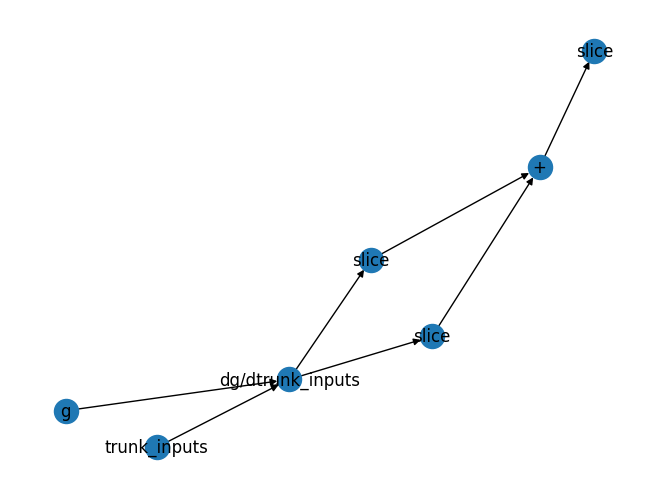

In [32]:
res_pde.show()

In [ ]:
# IC loss on boundary slice (train_x_bc)
u_ic = u[:, :num_bc]
v_ic = v[:, :num_bc]  # v(x) at t=0 points
ic_loss = (u_ic == v_ic) ^ 2
ic_loss.name = "ic"

In [36]:
print(v_ic({**net_out, **train_datadict.datadict}).shape)
print(u_ic({**net_out, **train_datadict.datadict}).shape)

torch.Size([1000, 50])
torch.Size([1000, 50])


In [37]:
loss = PenaltyLoss(objectives=[pde_loss, ic_loss], constraints=[])

`Problem` setup using both DeepONets is similar. The Neuromancer library gives you the choice of seamlessly adding any approximator of choice in your `Problem` framework

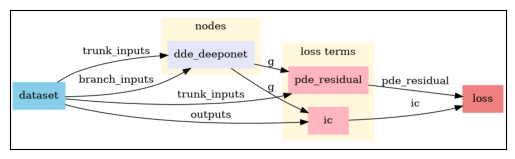

In [38]:
problem = Problem(
    nodes=[node_dde_deeponet],  # list of nodes (neural nets) to be optimized
    loss=loss,  # physics-informed loss function
    grad_inference=True,
)  # argument for allowing computation of gradients at the inference time)
problem.show()  # graphviz library needed for graph visualization

## Problem Solution in NeuroMANCER

In [ ]:
lr = 0.0005  # step size for gradient descent
epochs = 500  # number of training epochs
epoch_verbose = 10  # print loss/display loss plot when this many epochs have occurred
warmup = 100  # number of epochs to wait before enacting early stopping policy
patience = 0  # number of epochs with no improvement in eval metric to allow before early stopping

optimizer = torch.optim.Adam(problem.parameters(), lr=lr)


### Construct Trainer and solve the problem

In [74]:
from neuromancer.trainer import Trainer
from neuromancer.callbacks import LossHistoryCallback

# define loss history callback using plots
loss_history_callback = LossHistoryCallback(plots_dir=None, show=True)
# dev_loader = train_loader  # reuse

# define trainer
trainer = Trainer(
    problem.to(device),
    train_data=train_loader,
    # dev_data=train_loader,
    # test_data=test_loader,
    optimizer=optimizer,
    logger=None,
    callback=loss_history_callback,
    epochs=epochs,
    patience=patience,
    epoch_verbose=epoch_verbose,
    train_metric="train_loss",
    dev_metric="train_loss",
    # test_metric="test_loss",
    eval_metric="train_loss",
    warmup=warmup,
    device=device,
)

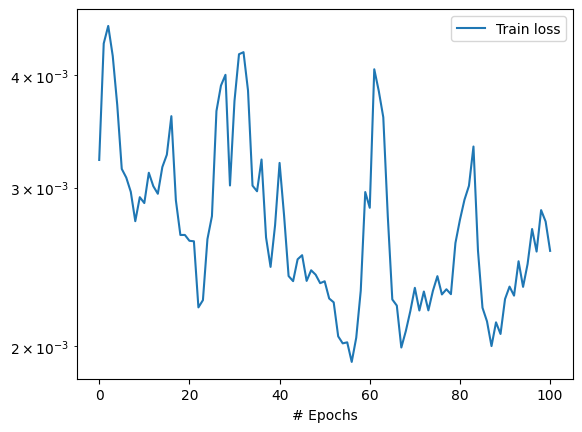

Early stopping!!!
CPU times: user 19.3 s, sys: 2.68 s, total: 22 s
Wall time: 21.5 s


In [75]:
%%time
best_model = trainer.train()

In [78]:
# load best trained model
# best_outputs = trainer.test(best_model)
problem.load_state_dict(best_model)

<All keys matched successfully>

In [79]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
# dev_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["dev"]]
# mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
# print(mean_test_loss)
print(f"len(train_loss_history): {len(train_loss_history)}")
# print(f"len(dev_loss_history): {len(dev_loss_history)}")

len(train_loss_history): 102


## Plot loss history w/ mean test loss

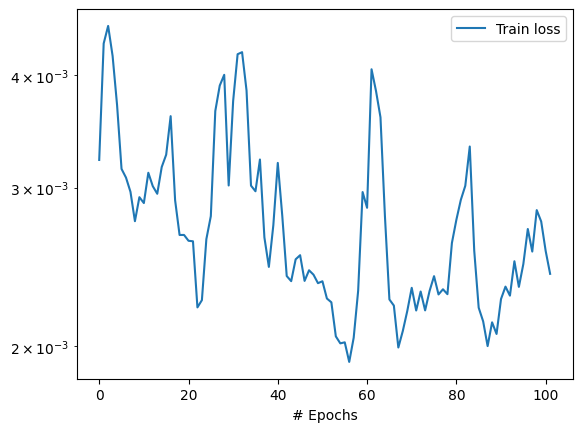

In [80]:
plt.semilogy(train_loss_history, label="Train loss")
# plt.semilogy(dev_loss_history, label="Dev loss")
# plt.scatter(
#     len(train_loss_history), mean_test_loss, label="Mean test loss", c="red", marker="x"
# )
plt.xlabel("# Epochs")
plt.legend()
plt.show()

## Compare results on the test data

In [81]:
# load best trained model (already in your notebook)
# problem.load_state_dict(best_model)
problem.eval()

k = 21  # which test function to visualize
v = test_datadict.datadict["branch_inputs"][k : k + 1].to(device)  # (1, m_eval)
xt = test_datadict.datadict["trunk_inputs"][k : k + 1].to(device)  # (1, m_trunk, 2)

with torch.no_grad():
    res = problem.predict({"branch_inputs": v, "trunk_inputs": xt})
u_pred = res["g"][0].detach().cpu().numpy()  # (m_trunk,)

v_exact = test_datadict.datadict["outputs"][k].detach().cpu().numpy()  # (m_trunk,)

print(f"u_pred.shape: {u_pred.shape}")
print(f"v_exact.shape: {v_exact.shape}")
print(f"xt.shape: {xt.shape}")


u_pred.shape: (450,)
v_exact.shape: (450,)
xt.shape: torch.Size([1, 450, 2])


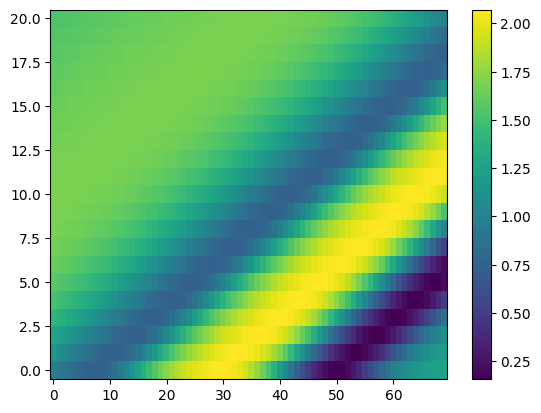

In [84]:
x = np.linspace(0, 1, len(x))
t = np.linspace(0, 1, len(t))
xv, tv = np.meshgrid(x, t)
xt_grid = np.stack([xv.ravel(), tv.ravel()], axis=-1)

v = test_datadict.datadict["branch_inputs"][k : k + 1].to(device)
xt = torch.tensor(xt_grid, dtype=torch.float32, device=device).unsqueeze(0)

with torch.no_grad():
    res = problem.predict({"branch_inputs": v, "trunk_inputs": xt})
u_pred = res["g"][0].detach().cpu().numpy().reshape(len(t), len(x))

plt.figure()
plt.imshow(u_pred, origin="lower", aspect="auto")
plt.colorbar()
plt.show()


u_pred.shape: (450,)
v_exact.shape: (450,)
xt.shape: torch.Size([1, 450, 2])


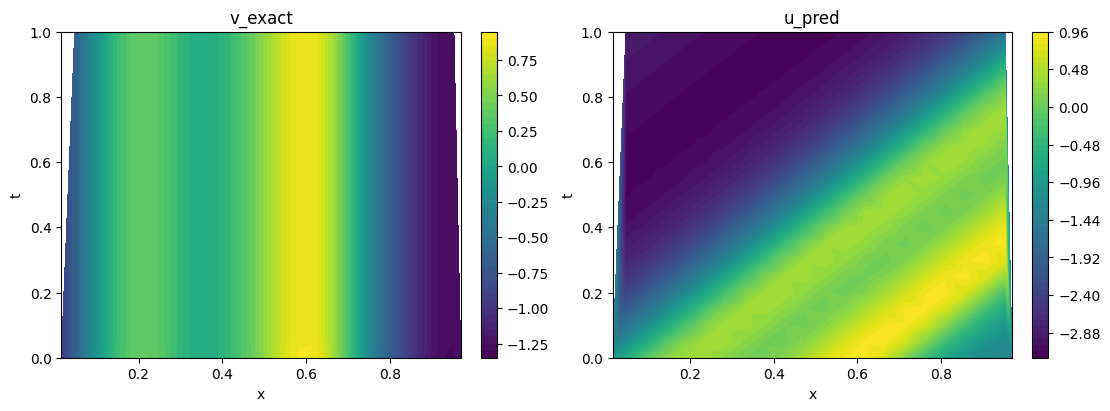

In [89]:
import matplotlib.tri as mtri

k = 44
v = test_datadict.datadict["branch_inputs"][k : k + 1].to(device)
xt = test_datadict.datadict["trunk_inputs"][k : k + 1].to(device)

with torch.no_grad():
    res = problem.predict({"branch_inputs": v, "trunk_inputs": xt})

u_pred = res["g"][0].detach().cpu().numpy()
v_exact = test_datadict.datadict["outputs"][k].detach().cpu().numpy()
xt_np = xt[0].detach().cpu().numpy()

print(f"u_pred.shape: {u_pred.shape}")
print(f"v_exact.shape: {v_exact.shape}")
print(f"xt.shape: {xt.shape}")

tri = mtri.Triangulation(xt_np[:, 0], xt_np[:, 1])

fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
c0 = ax[0].tricontourf(tri, v_exact, levels=50)
fig.colorbar(c0, ax=ax[0])
ax[0].set_title("v_exact")

c1 = ax[1].tricontourf(tri, u_pred, levels=50)
fig.colorbar(c1, ax=ax[1])
ax[1].set_title("u_pred")

for a in ax:
    a.set_xlabel("x")
    a.set_ylabel("t")
plt.show()


Compare model predictions to the analytic solution u(x, t) = sin(2π(x − t)) on irregular collocation points using triangulated contours.


u_pred.shape: (450,)
u_true.shape: (450,)
xt.shape: torch.Size([1, 450, 2])


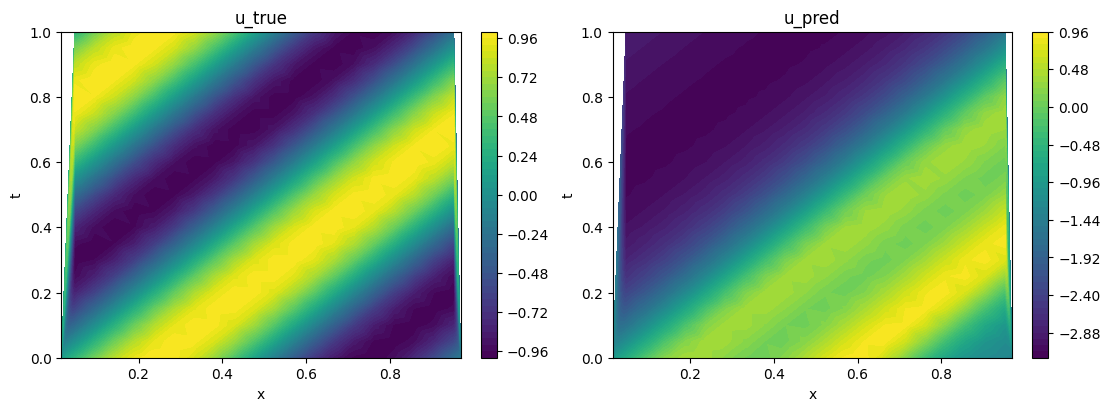

In [90]:
import matplotlib.tri as mtri

k = 44
v = test_datadict.datadict["branch_inputs"][k : k + 1].to(device)
xt = test_datadict.datadict["trunk_inputs"][k : k + 1].to(device)

with torch.no_grad():
    res = problem.predict({"branch_inputs": v, "trunk_inputs": xt})

u_pred = res["g"][0].detach().cpu().numpy()
xt_np = xt[0].detach().cpu().numpy()

u_true = np.sin(2 * np.pi * (xt_np[:, 0] - xt_np[:, 1]))

print(f"u_pred.shape: {u_pred.shape}")
print(f"u_true.shape: {u_true.shape}")
print(f"xt.shape: {xt.shape}")

tri = mtri.Triangulation(xt_np[:, 0], xt_np[:, 1])

fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
c0 = ax[0].tricontourf(tri, u_true, levels=50)
fig.colorbar(c0, ax=ax[0])
ax[0].set_title("u_true")

c1 = ax[1].tricontourf(tri, u_pred, levels=50)
fig.colorbar(c1, ax=ax[1])
ax[1].set_title("u_pred")

for a in ax:
    a.set_xlabel("x")
    a.set_ylabel("t")
plt.show()
